In [1]:
%cd ..
import pydicom
import os

/Users/anne-gabrielle/Le_Neuro/DeepMRAC


In [2]:
def check_series(folder):
    all_files = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))]
    nb_files = len(all_files)
    
    if nb_files == 0:
        print(f"The folder {folder} is empty.")
        return

    first_file = all_files[0]
    ds = pydicom.dcmread(os.path.join(folder, first_file))
    
    print(f"Folder: {folder}")
    print(f"  - Description: {ds.SeriesDescription}")
    print(f"  - Modality:    {ds.Modality}")
    print(f"  - Matrice:     {ds.Rows}x{ds.Columns}")
    print(f"  - Files number: {nb_files}")
    print(f"  - Echo Time: {ds.EchoTime}")
    print(f"  - Field: {ds.MagneticFieldStrength}T")
    print("-" * 30)

check_series('./datasets/ute/MRAC_UTE_0019')
check_series('./datasets/ute/MRAC_UTE_0020')
check_series('./datasets/ute/MRAC_UTE_UMAP_0021')

Folder: ./datasets/ute/MRAC_UTE_0019
  - Description: MRAC_UTE
  - Modality:    MR
  - Matrice:     192x192
  - Files number: 192
  - Echo Time: 0.07
  - Field: 3T
------------------------------
Folder: ./datasets/ute/MRAC_UTE_0020
  - Description: MRAC_UTE
  - Modality:    MR
  - Matrice:     192x192
  - Files number: 192
  - Echo Time: 2.46
  - Field: 3T
------------------------------
Folder: ./datasets/ute/MRAC_UTE_UMAP_0021
  - Description: MRAC_UTE_UMAP
  - Modality:    MR
  - Matrice:     192x192
  - Files number: 192
  - Echo Time: 2.46
  - Field: 3T
------------------------------


# Using ute_utils.py

In [3]:
from deepmrac.ute_utils import sort_files, load_data, to_dcm
from deepmrac.predictions import predict_DeepUTE
from deepmrac.metrics import calculate_quality_metrics, save_metrics_to_csv

In [4]:
tmpdir="./temp_file"
ute1_path="./datasets/ute/MRAC_UTE_0019"
ute2_path="./datasets/ute/MRAC_UTE_0020"
umap_path="./datasets/ute/MRAC_UTE_UMAP_0021"
version="VE11P"
verbose=True
output_folder=f"./output/ute_original"

In [7]:
# Sort files into specific folders
sort_files(source_folder=ute1_path, temp_subfolder=f"{tmpdir}/ute1_dcm", verbose=verbose )
sort_files(source_folder=ute2_path, temp_subfolder=f"{tmpdir}/ute2_dcm", verbose=verbose )
sort_files(source_folder=umap_path, temp_subfolder=f"{tmpdir}/umap_dcm", verbose=verbose )
        

Processing files in: ./datasets/ute/MRAC_UTE_0019
Processing files in: ./datasets/ute/MRAC_UTE_0020
Processing files in: ./datasets/ute/MRAC_UTE_UMAP_0021


In [8]:
# Load data
ute1, ute2 = load_data(temp_folder=tmpdir)

In [10]:
pred = predict_DeepUTE(ute1=ute1, ute2=ute2, version=version)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 

In [11]:
to_dcm(DeepX=pred, dcmcontainer=f"{tmpdir}/umap_dcm", dicomfolder=output_folder)

# Using T1_utils.py

In [12]:
from deepmrac.utils import sort_files, load_and_resample_images, resample_to_output_format, convert_to_nifti, to_dcm
from deepmrac.predictions import predict_DeepUTE
from deepmrac.metrics import calculate_quality_metrics, save_metrics_to_csv
import nibabel as nib
import numpy as np

In [13]:
tmpdir="./temp_file2"
ute1_path="./datasets/ute/MRAC_UTE_0019"
ute2_path="./datasets/ute/MRAC_UTE_0020"
umap_path="./datasets/ute/MRAC_UTE_UMAP_0021"
verbose=True
version='VE11P'
output_folder=f"./output/ute"

In [14]:
# Sort files into specific folders
sort_files(source_folder=ute1_path, temp_subfolder=f"{tmpdir}/ute1_dcm", verbose=verbose )
sort_files(source_folder=ute2_path, temp_subfolder=f"{tmpdir}/ute2_dcm", verbose=verbose )
sort_files(source_folder=umap_path, temp_subfolder=f"{tmpdir}/umap_dcm", verbose=verbose )

Found files in ./datasets/ute/MRAC_UTE_0019. Making copy
Found files in ./datasets/ute/MRAC_UTE_0020. Making copy
Found files in ./datasets/ute/MRAC_UTE_UMAP_0021. Making copy


In [15]:
convert_to_nifti(dicom_dir=f"{tmpdir}/ute1_dcm", output_nii=f"{tmpdir}/ute1.nii.gz", verbose=verbose)
convert_to_nifti(dicom_dir=f"{tmpdir}/ute2_dcm", output_nii=f"{tmpdir}/ute2.nii.gz", verbose=verbose)
convert_to_nifti(dicom_dir=f"{tmpdir}/umap_dcm", output_nii=f"{tmpdir}/umap.nii.gz", verbose=verbose)

Converting ./temp_file2/ute1_dcm to ./temp_file2/ute1.nii.gz
Converting ./temp_file2/ute2_dcm to ./temp_file2/ute2.nii.gz
Converting ./temp_file2/umap_dcm to ./temp_file2/umap.nii.gz


In [16]:
ute1_rsl, ute1_ref = load_and_resample_images(nii_image=f"{tmpdir}/ute1.nii.gz", verbose=verbose)
ute2_rsl, ute2_ref = load_and_resample_images(nii_image=f"{tmpdir}/ute2.nii.gz", verbose=verbose)
umap_nat = nib.load(f'{tmpdir}/umap.nii.gz')

Loading and resampling data from ./temp_file2/ute1.nii.gz.
Loading and resampling data from ./temp_file2/ute2.nii.gz.


In [17]:
pred = predict_DeepUTE(ute1=ute1_rsl, ute2=ute2_rsl, version=version)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [18]:
DeepX = np.flip(pred, axis=1)
DeepX = resample_to_output_format(pred=DeepX, model_ref=ute1_ref, umap_native=umap_nat, rmi_type="UTE", verbose=verbose, save_prediction=True)

Resampling to Umap format
Saving QC nii file to DeepUTE_QC.nii.gz


In [19]:
DeepX = np.transpose(DeepX, (2, 1, 0))
to_dcm(DeepX=DeepX, dcmcontainer=f"{tmpdir}/umap_dcm", dicomfolder=output_folder, rmi_type="UTE")

# Visualisation

In [20]:
import matplotlib.pyplot as plt
import pydicom
import os

def plot_dicom_file(file):
    ds = pydicom.dcmread(file)

    data = ds.pixel_array
    print(f"Max value: {data.max()}")
    print(f"Min value: {data.min()}")
    print(f"Mean value: {data.mean()}")
    print(f"Dimensions : {ds.Rows}x{ds.Columns}")
    
    plt.imshow(data, cmap='gray')
    plt.title(f"Slice {ds.InstanceNumber} - {ds.SeriesDescription}")
    plt.show()

def scan_folder_for_data(folder):
    files = sorted([os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith(('.ima', '.dcm'))])
    print(f"{len(files)} files found...")
    
    valid_files_count = 0
    
    for f in files:
        try:
            ds = pydicom.dcmread(f)
            pixel_max = ds.pixel_array.max()
            
            if pixel_max > 0:
                print(f"✅ {os.path.basename(f)} | Max : {pixel_max}")
                valid_files_count += 1
                
        except Exception as e:
            print(f"An error occured when trying to read {os.path.basename(f)} : {e}")
            
    print("-" * 30)
    if valid_files_count > 0:
        print(f"Result : {valid_files_count}/{len(files)} files have data.")
    else:
        print("Results : No data found in any of the files.")

## Deep learning outcom

In [21]:
scan_folder_for_data("./output/ute")

192 files found...
✅ dicom_0002.dcm | Max : 940
✅ dicom_0003.dcm | Max : 1109
✅ dicom_0004.dcm | Max : 1172
✅ dicom_0005.dcm | Max : 1187
✅ dicom_0006.dcm | Max : 1242
✅ dicom_0007.dcm | Max : 1250
✅ dicom_0008.dcm | Max : 1360
✅ dicom_0009.dcm | Max : 1421
✅ dicom_0010.dcm | Max : 1324
✅ dicom_0011.dcm | Max : 1308
✅ dicom_0012.dcm | Max : 1262
✅ dicom_0013.dcm | Max : 1313
✅ dicom_0014.dcm | Max : 1357
✅ dicom_0015.dcm | Max : 1392
✅ dicom_0016.dcm | Max : 1396
✅ dicom_0017.dcm | Max : 1374
✅ dicom_0018.dcm | Max : 1354
✅ dicom_0019.dcm | Max : 1302
✅ dicom_0020.dcm | Max : 1341
✅ dicom_0021.dcm | Max : 1369
✅ dicom_0022.dcm | Max : 1359
✅ dicom_0023.dcm | Max : 1326
✅ dicom_0024.dcm | Max : 1286
✅ dicom_0025.dcm | Max : 1277
✅ dicom_0026.dcm | Max : 1329
✅ dicom_0027.dcm | Max : 1473
✅ dicom_0028.dcm | Max : 1479
✅ dicom_0029.dcm | Max : 1512
✅ dicom_0030.dcm | Max : 1586
✅ dicom_0031.dcm | Max : 1527
✅ dicom_0032.dcm | Max : 1490
✅ dicom_0033.dcm | Max : 1512
✅ dicom_0034.dcm | Max

In [22]:
scan_folder_for_data("./output/ute_original")

192 files found...
✅ dicom_0001.dcm | Max : 1409
✅ dicom_0002.dcm | Max : 1426
✅ dicom_0003.dcm | Max : 1363
✅ dicom_0004.dcm | Max : 1300
✅ dicom_0005.dcm | Max : 1279
✅ dicom_0006.dcm | Max : 1308
✅ dicom_0007.dcm | Max : 1300
✅ dicom_0008.dcm | Max : 1357
✅ dicom_0009.dcm | Max : 1399
✅ dicom_0010.dcm | Max : 1413
✅ dicom_0011.dcm | Max : 1353
✅ dicom_0012.dcm | Max : 1279
✅ dicom_0013.dcm | Max : 1323
✅ dicom_0014.dcm | Max : 1348
✅ dicom_0015.dcm | Max : 1314
✅ dicom_0016.dcm | Max : 1346
✅ dicom_0017.dcm | Max : 1398
✅ dicom_0018.dcm | Max : 1433
✅ dicom_0019.dcm | Max : 1453
✅ dicom_0020.dcm | Max : 1464
✅ dicom_0021.dcm | Max : 1402
✅ dicom_0022.dcm | Max : 1462
✅ dicom_0023.dcm | Max : 1593
✅ dicom_0024.dcm | Max : 1589
✅ dicom_0025.dcm | Max : 1657
✅ dicom_0026.dcm | Max : 1634
✅ dicom_0027.dcm | Max : 1644
✅ dicom_0028.dcm | Max : 1575
✅ dicom_0029.dcm | Max : 1577
✅ dicom_0030.dcm | Max : 1537
✅ dicom_0031.dcm | Max : 1557
✅ dicom_0032.dcm | Max : 1522
✅ dicom_0033.dcm | Ma

Max value: 1239
Min value: 0
Mean value: 221.20033094618054
Dimensions : 192x192


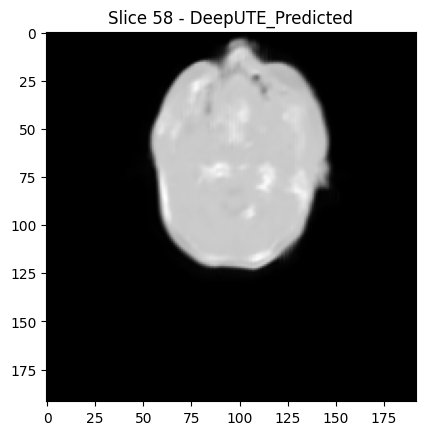

In [23]:
plot_dicom_file("./output/ute/dicom_0058.dcm")

Max value: 1439
Min value: 0
Mean value: 210.20000542534723
Dimensions : 192x192


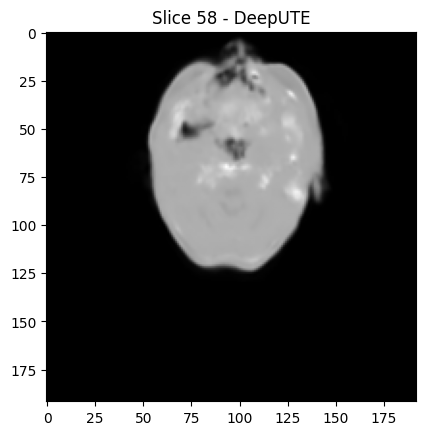

In [24]:
plot_dicom_file("./output/ute_original/dicom_0058.dcm")

## Original Umaps

In [25]:
scan_folder_for_data("./datasets/ute/MRAC_UTE_UMAP_0021")

192 files found...
✅ REMIND_005.MR.BRAIN_ANAZODO.0021.0003.2021.07.21.11.01.51.767833.62213299.IMA | Max : 1000
✅ REMIND_005.MR.BRAIN_ANAZODO.0021.0004.2021.07.21.11.01.51.767833.62213316.IMA | Max : 1000
✅ REMIND_005.MR.BRAIN_ANAZODO.0021.0005.2021.07.21.11.01.51.767833.62213333.IMA | Max : 1000
✅ REMIND_005.MR.BRAIN_ANAZODO.0021.0006.2021.07.21.11.01.51.767833.62213350.IMA | Max : 1510
✅ REMIND_005.MR.BRAIN_ANAZODO.0021.0007.2021.07.21.11.01.51.767833.62213367.IMA | Max : 1510
✅ REMIND_005.MR.BRAIN_ANAZODO.0021.0008.2021.07.21.11.01.51.767833.62213384.IMA | Max : 1510
✅ REMIND_005.MR.BRAIN_ANAZODO.0021.0009.2021.07.21.11.01.51.767833.62213401.IMA | Max : 1510
✅ REMIND_005.MR.BRAIN_ANAZODO.0021.0010.2021.07.21.11.01.51.767833.62213418.IMA | Max : 1510
✅ REMIND_005.MR.BRAIN_ANAZODO.0021.0011.2021.07.21.11.01.51.767833.62213435.IMA | Max : 1510
✅ REMIND_005.MR.BRAIN_ANAZODO.0021.0012.2021.07.21.11.01.51.767833.62213452.IMA | Max : 1510
✅ REMIND_005.MR.BRAIN_ANAZODO.0021.0013.2021.07.21.

Max value: 1510
Min value: 0
Mean value: 219.71978081597223
Dimensions : 192x192


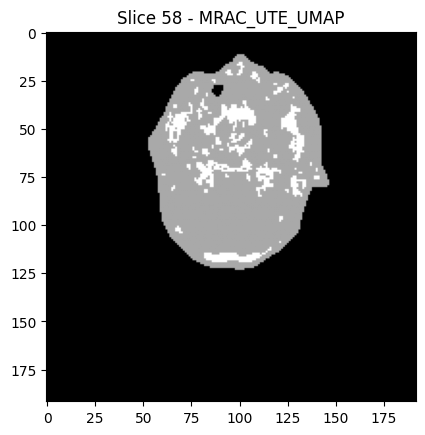

In [26]:
plot_dicom_file("./datasets/ute/MRAC_UTE_UMAP_0021/REMIND_005.MR.BRAIN_ANAZODO.0021.0058.2021.07.21.11.01.51.767833.62214234.IMA")

## UTE dicoms

Max value: 2176
Min value: 0
Mean value: 195.88362630208334
Dimensions : 192x192


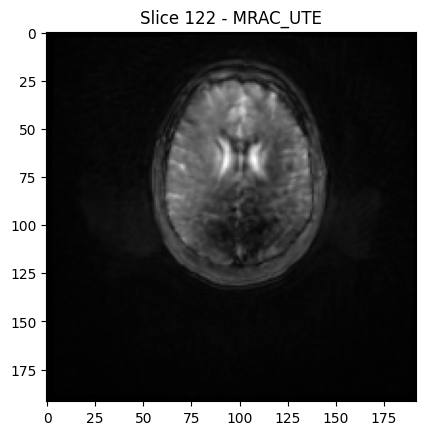

In [27]:
plot_dicom_file("./datasets/ute/MRAC_UTE_0019/REMIND_005.MR.BRAIN_ANAZODO.0019.0122.2021.07.21.11.01.51.767833.62208762.IMA")